Importing Depedenceies

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Test the imports
print("Dependencies imported successfully!")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")

Dependencies imported successfully!
pandas version: 2.2.3
numpy version: 2.2.3


Loading the data and viewing the top rows of the data

In [2]:
df = pd.read_csv('../data/kenya.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85
1,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65
2,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60
3,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64
4,2015,6,20.89,29.94,12.47,17.47,0.01,53.78,2.73,4.00,83.63,9.05


Viewing the bottom rows of the dataset

In [3]:
print (pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j"))

0      2015-01-02
1      2015-01-03
2      2015-01-04
3      2015-01-05
4      2015-01-06
          ...    
4102   2026-03-27
4103   2026-03-28
4104   2026-03-29
4105   2026-03-30
4106   2026-03-31
Length: 4107, dtype: datetime64[ns]


Overview of random sample

Using df.describe() to get statistical summary of the numerical columns in a DataFrame

In [4]:
print("summary statistics")
display(df.describe())

summary statistics


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000
mean,2020.132700,180.164841,20.427811,27.838437,14.673798,13.164638,1.468520,65.850353,3.061751,4.375147,83.724346,11.053555
std,3.248315,106.270943,1.440936,2.358989,1.415289,2.604839,3.180533,9.930239,0.853321,0.992258,0.126405,1.606027
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000
25%,2017.000000,86.000000,19.460000,26.295000,13.700000,11.465000,0.100000,58.685000,2.420000,3.670000,83.630000,9.880000
50%,2020.000000,179.000000,20.360000,27.870000,14.750000,13.260000,0.380000,66.230000,3.140000,4.430000,83.720000,11.010000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000


In [5]:
# Replace all -999 values with np.nan (NASA missing value sentinel)
df.replace(-999, np.nan, inplace=True)

Overview of categorical columns

In [6]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4107 entries, 0 to 4106
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YEAR         4107 non-null   int64  
 1   DOY          4107 non-null   int64  
 2   T2M          4107 non-null   float64
 3   T2M_MAX      4107 non-null   float64
 4   T2M_MIN      4107 non-null   float64
 5   T2M_RANGE    4107 non-null   float64
 6   PRECTOTCORR  4107 non-null   float64
 7   RH2M         4107 non-null   float64
 8   WS2M         4107 non-null   float64
 9   WS2M_MAX     4107 non-null   float64
 10  PS           4107 non-null   float64
 11  QV2M         4107 non-null   float64
dtypes: float64(10), int64(2)
memory usage: 385.2 KB
None


Missing Values

In [7]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64

Handling missing values

In [8]:
# df = df.drop(columns=['Comments'])

Checking for the negative values in T2M, T2M_MAX, T2M_RANGE, PRECTOTCORR, WS2M, WS2M_MAX

In [9]:
radiation_cols=['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','RH2M','PRECTOTCORR','WS2M','WS2M_MAX']
negative_cols = (df[radiation_cols]<0).sum()
print("Negative values in radiation columns:\n", negative_cols)

Negative values in radiation columns:
 T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
RH2M           0
PRECTOTCORR    0
WS2M           0
WS2M_MAX       0
dtype: int64


Checking duplicates

In [10]:
# Exact duplicate rows
dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)

# Cardinality (uniqueness) for categoricals
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
cardinality = {c: df[c].nunique() for c in cat_cols}
print("Cardinality (categoricals):", cardinality)


Duplicate rows: 0
Cardinality (categoricals): {}


In [11]:
print(" compute the percentage of missing values per column")
print(df.isna().sum())

 compute the percentage of missing values per column
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


Identify outliers using z-scores

In [12]:
cols_to_check = ['T2M','T2M_MAX','T2M_MIN','T2M_RANGE','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']

In [13]:
z_scores= np.abs(stats.zscore(df[cols_to_check]))

In [14]:
outliers_mask=(z_scores>3).any(axis=1)

In [15]:
print(f"\nRows flagged as outliers: {outliers_mask.sum()}")


Rows flagged as outliers: 127


In [16]:
df_clean = df[~outliers_mask].copy()

In [17]:
print(f"Original rows: {len(df)}")
print(f"Cleaned rows:{len(df_clean)}")

Original rows: 4107
Cleaned rows:3980


### Handling Remaining Missing Values

- Rows with more than 30% missing values were dropped to avoid introducing bias from excessive imputation.
- For the remaining missing values in weather-related columns, forward-fill was applied. This is appropriate for time-series weather data, as it assumes the previous value is a reasonable estimate for the missing entry.

In [18]:
# 1. Drop rows with more than 30% missing values
threshold = int(0.3 * df.shape[1])
df = df.dropna(thresh=df.shape[1] - threshold)

# 2. Forward-fill for weather variables
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

# 3. Documenting the decision
print("Rows with more than 30% missing values were dropped.")
print("Remaining missing values in weather variables were forward-filled.")
print("Missing values after cleaning:\n", df.isna().sum())

Rows with more than 30% missing values were dropped.
Remaining missing values in weather variables were forward-filled.
Missing values after cleaning:
 YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [19]:
# Export the cleaned DataFrame to data/ethiopia_clean.csv
df.to_csv('../data/kenya_clean.csv', index=False)
print("Cleaned data exported to data/kenya_clean.csv")

Cleaned data exported to data/kenya_clean.csv


Monthly Average T2M (2015–2026)

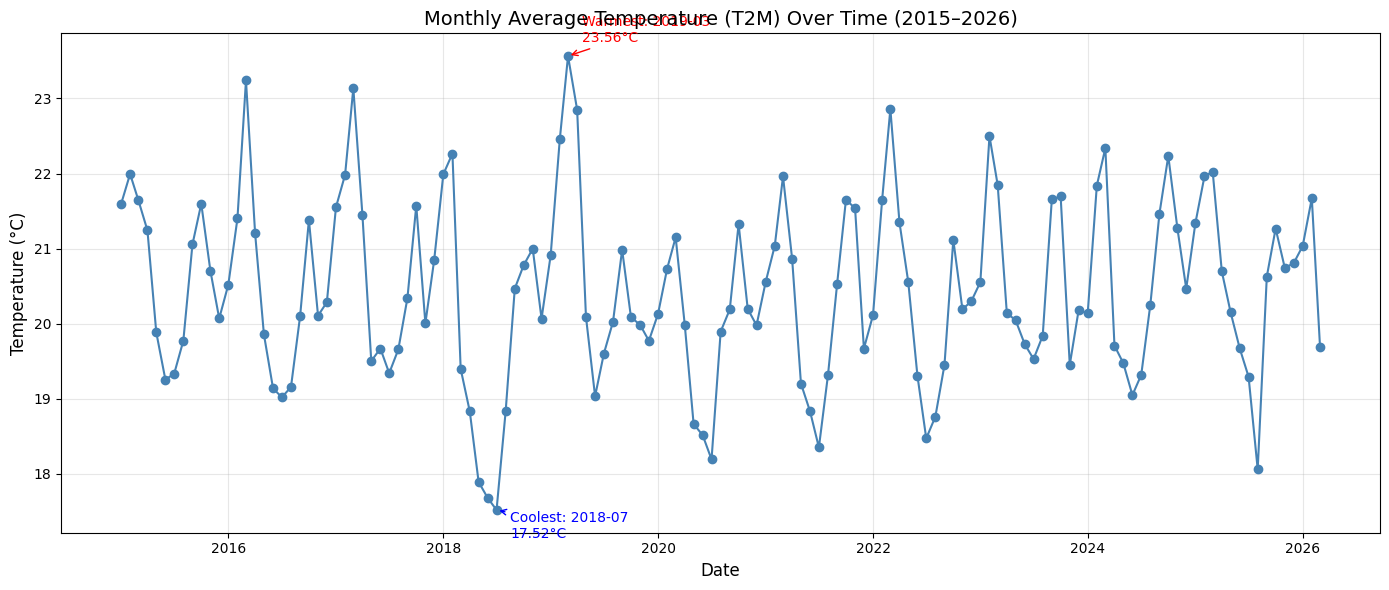

In [20]:
# Create DATE from YEAR and DOY (day of year)
df['DATE'] = pd.to_datetime(df['YEAR'].astype(str) + df['DOY'].astype(str), format='%Y%j')
df['YearMonth'] = df['DATE'].dt.to_period('M')

# Calculate monthly average T2M
monthly_t2m = df.groupby('YearMonth')['T2M'].mean().reset_index()
monthly_t2m['YearMonth'] = monthly_t2m['YearMonth'].dt.to_timestamp()

# Find warmest and coolest months
warmest_idx = monthly_t2m['T2M'].idxmax()
coolest_idx = monthly_t2m['T2M'].idxmin()
warmest_month = monthly_t2m.loc[warmest_idx]
coolest_month = monthly_t2m.loc[coolest_idx]

# Plot using plt
plt.figure(figsize=(14, 6))
plt.plot(monthly_t2m['YearMonth'], monthly_t2m['T2M'], marker='o', linewidth=1.5, color='steelblue')

# Annotate warmest month
plt.annotate(f"Warmest: {warmest_month['YearMonth'].strftime('%Y-%m')}\n{warmest_month['T2M']:.2f}°C",
            xy=(warmest_month['YearMonth'], warmest_month['T2M']),
            xytext=(10, 10), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'),
            fontsize=10, color='red')

# Annotate coolest month
plt.annotate(f"Coolest: {coolest_month['YearMonth'].strftime('%Y-%m')}\n{coolest_month['T2M']:.2f}°C",
            xy=(coolest_month['YearMonth'], coolest_month['T2M']),
            xytext=(10, -20), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='blue'),
            fontsize=10, color='blue')

plt.title('Monthly Average Temperature (T2M) Over Time (2015–2026)', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Monthly Total PRECTOTCORR (Precipitation)

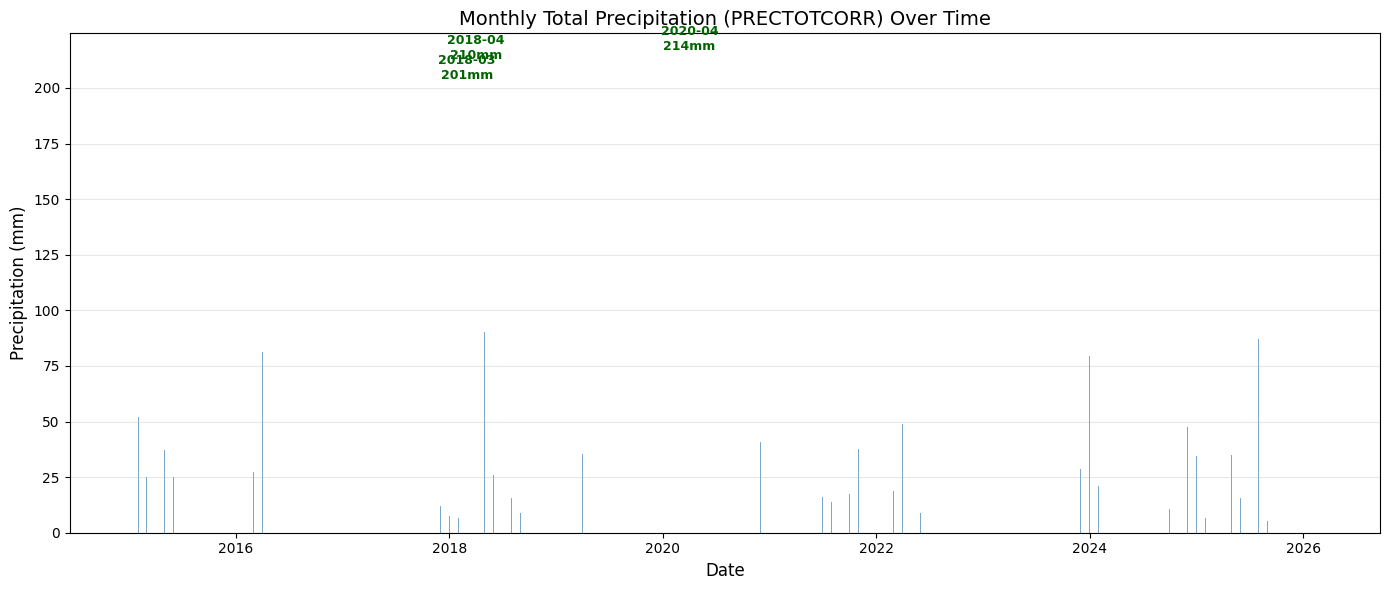


Top 3 Peak Rainy Season Months:
 YearMonth  PRECTOTCORR
2020-04-01       213.89
2018-04-01       209.74
2018-03-01       200.73


In [21]:
# Calculate monthly total precipitation
monthly_precip = df.groupby('YearMonth')['PRECTOTCORR'].sum().reset_index()
monthly_precip['YearMonth'] = monthly_precip['YearMonth'].dt.to_timestamp()

# Find peak rainy season months (top 3 months with highest precipitation)
top_3 = monthly_precip.nlargest(3, 'PRECTOTCORR')

# Plot as bar chart
plt.figure(figsize=(14, 6))
plt.bar(monthly_precip['YearMonth'], monthly_precip['PRECTOTCORR'], color='steelblue', alpha=0.7)

# Annotate peak months
for idx, row in top_3.iterrows():
    plt.annotate(f"{row['YearMonth'].strftime('%Y-%m')}\n{row['PRECTOTCORR']:.0f}mm",
                xy=(row['YearMonth'], row['PRECTOTCORR']),
                xytext=(0, 5), textcoords='offset points',
                ha='center', fontsize=9, color='darkgreen', fontweight='bold')

plt.title('Monthly Total Precipitation (PRECTOTCORR) Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\nTop 3 Peak Rainy Season Months:")
print(top_3.to_string(index=False))



### **Precipitation Trend Analysis**
This bar chart illustrates the **monthly total precipitation** over time.

* **Temporal Distribution:** The plot aggregates data by month to show rainfall variability across the years.
* **Peak Identification:** The script programmatically identifies and annotates the **top 3 months with the highest precipitation**, highlighting specific months (e.g., April 2020 at 214mm) where significant rainfall events occurred.
* **Visualization Logic:** The code uses `df.groupby('YearMonth')` to transform the time-series data, followed by `plt.bar` for visualization. Annotated markers with `plt.annotate` provide clear, direct labels for the peak rainfall events, enhancing interpretability.

Correlation Heatmap

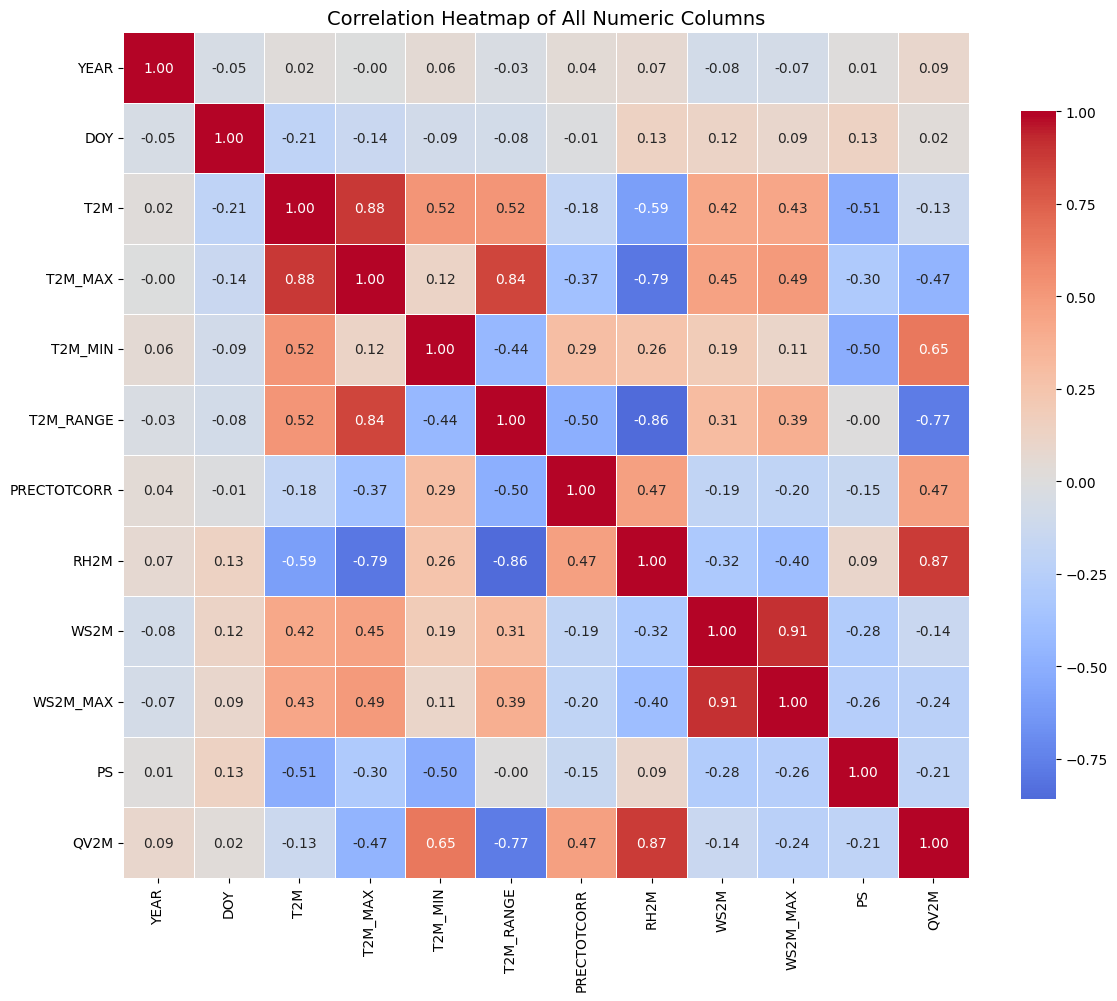

In [22]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of All Numeric Columns', fontsize=14)
plt.tight_layout()
plt.show()

Scatter Plots: Variable Relationships

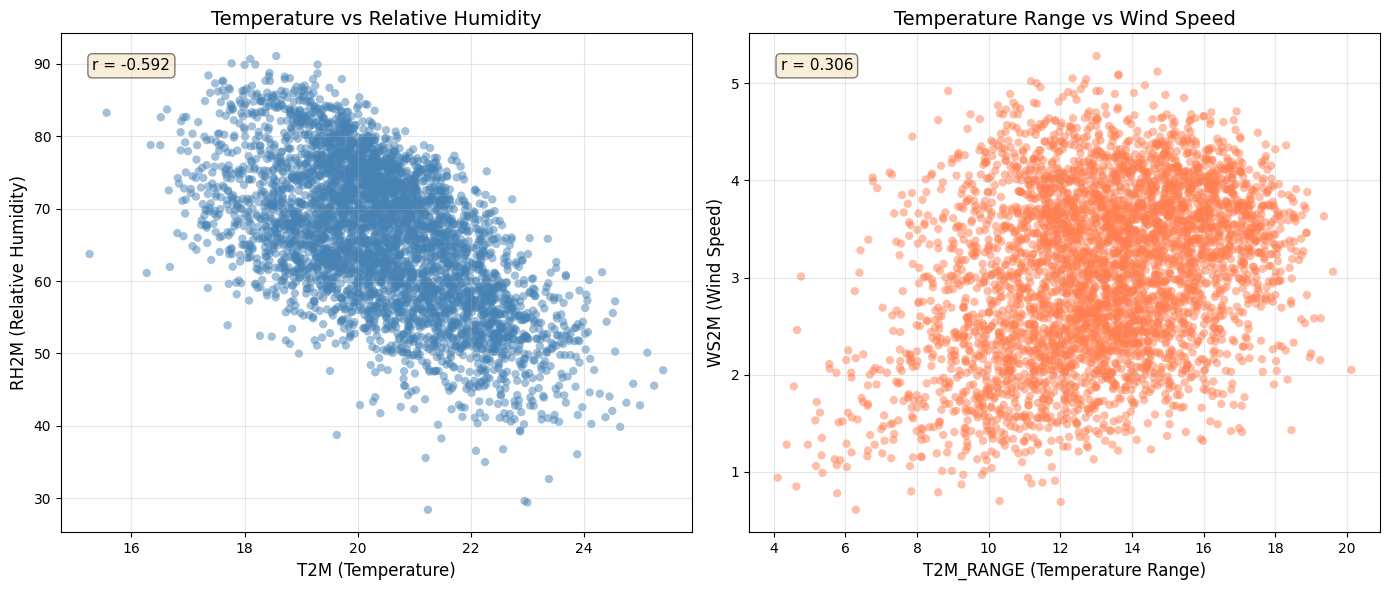

In [23]:
# Create scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: T2M vs RH2M
plt.subplot(1, 2, 1)
plt.scatter(df['T2M'], df['RH2M'], alpha=0.5, color='steelblue', edgecolors='none')
plt.xlabel('T2M (Temperature)', fontsize=12)
plt.ylabel('RH2M (Relative Humidity)', fontsize=12)
plt.title('Temperature vs Relative Humidity', fontsize=14)
plt.grid(True, alpha=0.3)
corr1 = df['T2M'].corr(df['RH2M'])
plt.text(0.05, 0.95, f'r = {corr1:.3f}', transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Plot 2: T2M_RANGE vs WS2M
plt.subplot(1, 2, 2)
plt.scatter(df['T2M_RANGE'], df['WS2M'], alpha=0.5, color='coral', edgecolors='none')
plt.xlabel('T2M_RANGE (Temperature Range)', fontsize=12)
plt.ylabel('WS2M (Wind Speed)', fontsize=12)
plt.title('Temperature Range vs Wind Speed', fontsize=14)
plt.grid(True, alpha=0.3)
corr2 = df['T2M_RANGE'].corr(df['WS2M'])
plt.text(0.05, 0.95, f'r = {corr2:.3f}', transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()



### **Correlation Analysis**
These side-by-side scatter plots compare the relationships between different meteorological variables, with **Pearson correlation coefficients ($r$)** annotated in each plot:

* **Temperature vs. Relative Humidity ($r = -0.592$):** Displays a **moderate negative correlation**. As the temperature (T2M) rises, relative humidity (RH2M) generally declines, which is consistent with atmospheric physical principles.
* **Temperature Range vs. Wind Speed ($r = 0.306$):** Shows a **weak positive correlation**. Higher daily temperature fluctuations (T2M_RANGE) appear slightly associated with increased wind speeds (WS2M).


**Key Visualization Design:**
The code uses `plt.subplots(1, 2)` to create a side-by-side layout, allowing for an efficient comparison of these distinct relationships within a single figure. Transparent markers (`alpha=0.5`) are used to better visualize data density and overlapping points.

Histogram of PRECTOTCORR (Precipitation)

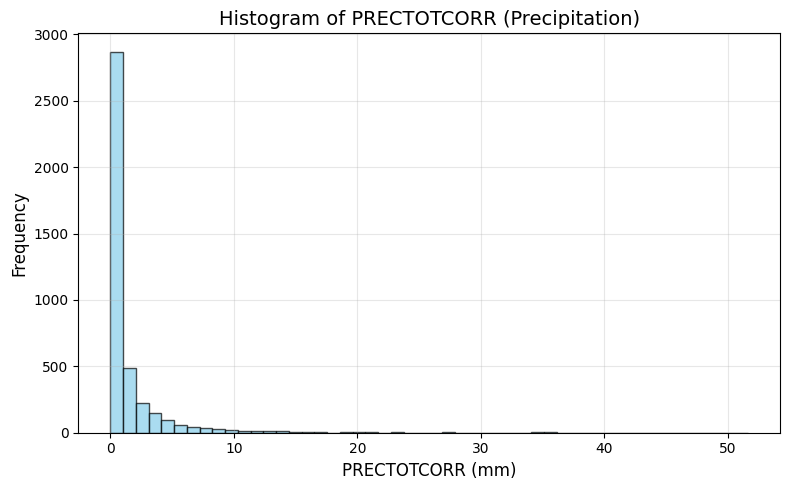

Skewness: 5.51


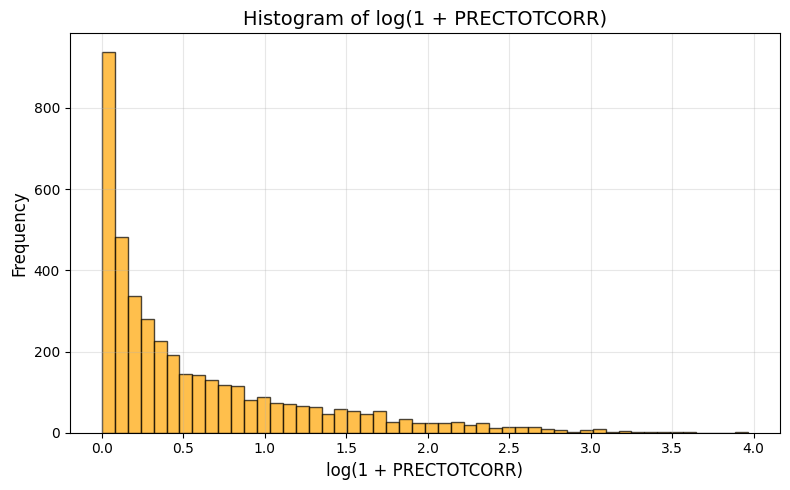

In [24]:
# Plot histogram of PRECTOTCORR
plt.figure(figsize=(8, 5))
plt.hist(df['PRECTOTCORR'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('PRECTOTCORR (mm)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Histogram of PRECTOTCORR (Precipitation)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check skewness
skew = df['PRECTOTCORR'].skew()
print(f"Skewness: {skew:.2f}")

# If heavily skewed, plot log scale
if skew > 1:
    plt.figure(figsize=(8, 5))
    plt.hist(np.log1p(df['PRECTOTCORR']), bins=50, color='orange', edgecolor='black', alpha=0.7)
    plt.xlabel('log(1 + PRECTOTCORR)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.title('Histogram of log(1 + PRECTOTCORR)', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

#### Distribution Shape Comment
- The histogram of PRECTOTCORR shows a strong right (positive) skew, with most days having low or zero precipitation and a long tail of higher values. This is typical for daily precipitation data, where dry days are common and heavy rainfall is rare.
- Applying a log transformation (log(1 + PRECTOTCORR)) makes the distribution more symmetric and easier to visualize, highlighting the spread among nonzero precipitation days.

Bubble Chart: T2M vs RH2M (Bubble Size = PRECTOTCORR)

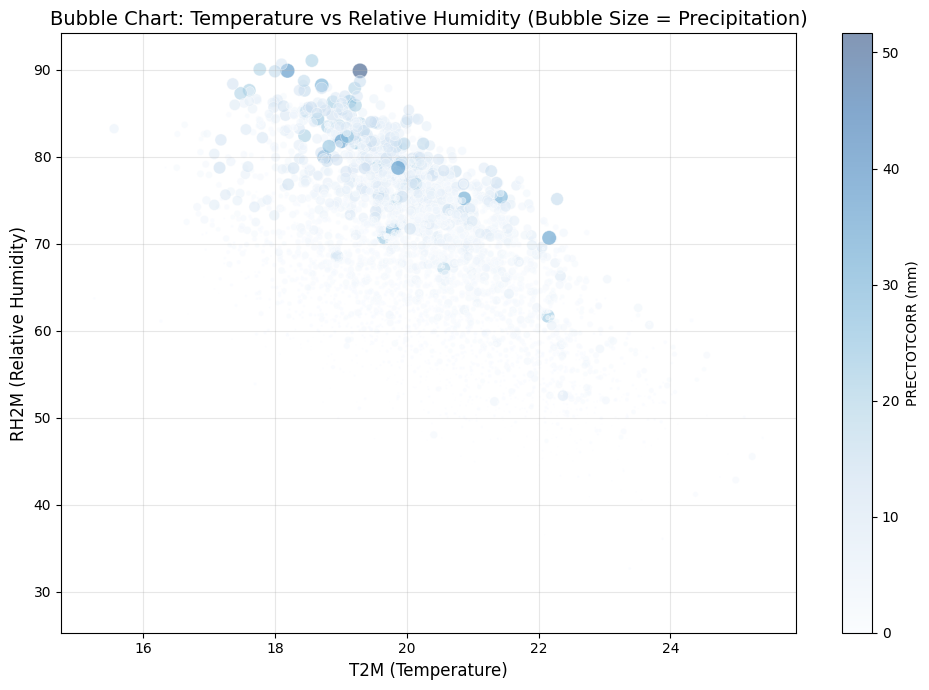

In [25]:
plt.figure(figsize=(10, 7))
sizes = np.log1p(df['PRECTOTCORR']) * 30  # log scale for better visibility, scale up for plotting
scatter = plt.scatter(df['T2M'], df['RH2M'], s=sizes, c=df['PRECTOTCORR'], cmap='Blues', alpha=0.5, edgecolors='w', linewidth=0.5)
plt.xlabel('T2M (Temperature)', fontsize=12)
plt.ylabel('RH2M (Relative Humidity)', fontsize=12)
plt.title('Bubble Chart: Temperature vs Relative Humidity (Bubble Size = Precipitation)', fontsize=14)
plt.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter)
cbar.set_label('PRECTOTCORR (mm)')
plt.tight_layout()
plt.show()


### This bubble chart visualizes the relationship between Temperature (T2M), Relative Humidity (RH2M), and Precipitation (PRECTOTCORR).

Axis Trends: The plot shows a clear negative correlation; as temperature increases, relative humidity tends to decrease.

Precipitation Patterns: Precipitation is represented by both bubble size and color intensity (using a 'Blues' colormap). High-precipitation events (larger, darker bubbles) cluster primarily in the upper-left region, indicating that significant rainfall correlates with lower temperatures and higher humidity.

Visualization Design: To manage high data density, alpha=0.5 was used for transparency, and precipitation values were log-scaled (np.log1p) to ensure visibility across the range of values.